# Pass 1: importaçãao das bibliotecas necessárias

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# pass 2: criação de dados ficticios que vão servir ao modelo. E visualização em gráfico

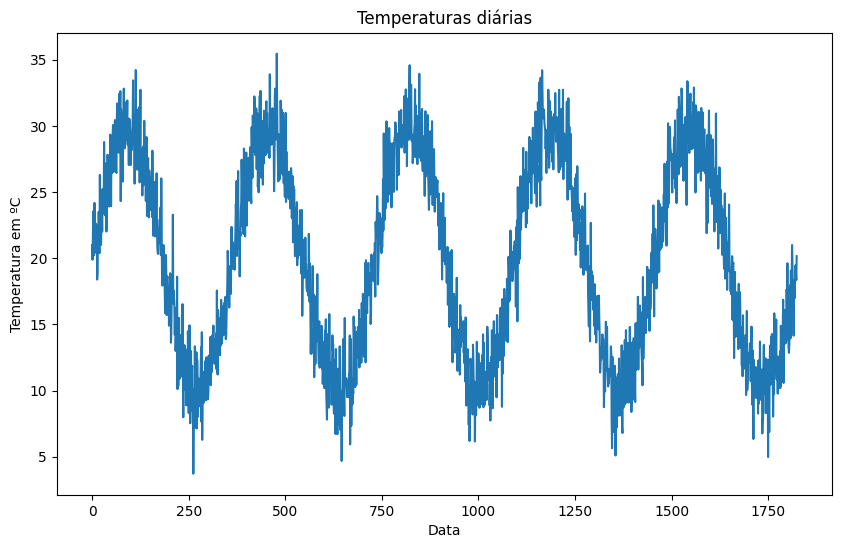

In [4]:
np.random.seed(42)
dias = 365 * 5
temperaturas = 20 + 10 * np.sin(2 * np.pi * np.arange(dias) / 365) + np.random.normal(0, 2, dias)

df = pd.DataFrame(temperaturas, columns=['Temperatura'])
df['Data'] = pd.date_range(start='2018-01-01', periods=dias, freq='D')

#visualização dos dados
plt.figure(figsize=(10, 6))
plt.plot(df['Temperatura'])
plt.title('Temperaturas diárias')
plt.xlabel('Data')
plt.ylabel('Temperatura em ºC')
plt.show()

# passo 3: pre-processamento dos dados

In [6]:
#normalização dos dados
scaler = MinMaxScaler(feature_range=(0, 1))
dados_normalizados = scaler.fit_transform(df[['Temperatura']])

x = []
y = []

for i in range(30, len(dados_normalizados)):
  x.append(dados_normalizados[i-30: i, 0])
  y.append(dados_normalizados[i, 0])

x, y = np.array(x), np.array(y)

x = np.reshape(x, (x.shape[0], x.shape[1], 1))

# passo 4: divisão dos dados de trino e teste

In [7]:
tamanho_treino = int(len(x) * 0.8)
Xtreino, Xteste = x[:tamanho_treino], x[tamanho_treino:]
Ytreino, Yteste = y[:tamanho_treino], y[tamanho_treino:]

# passo 5: construção do modelo de LSTM

In [8]:
modelo = Sequential()
modelo.add(LSTM(units=50, return_sequences=True, input_shape=(Xtreino.shape[1], 1)))
modelo.add(LSTM(units=50, return_sequences=False))
modelo.add(Dense(units=25))
modelo.add(Dense(units=1))

modelo.compile(optimizer='adam', loss= 'mean_squared_error')
modelo.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

# passo6: treinamento do modelo

In [10]:
modelo.fit(Xtreino, Ytreino, batch_size=32, epochs=20, validation_data=(Xteste, Yteste))

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0044 - val_loss: 0.0071
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0052 - val_loss: 0.0048
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0049 - val_loss: 0.0055
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0049 - val_loss: 0.0047
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0046 - val_loss: 0.0051
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0050 - val_loss: 0.0047
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0044 - val_loss: 0.0061
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0050 - val_loss: 0.0047
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0045 - val_loss: 0.0052
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0048 - val_loss: 0.0049
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0

# Passo 7: fazendo as previsões

In [11]:
previsao = modelo.predict(Xteste)
previsao = scaler.inverse_transform(previsao)

yteste_real = scaler.inverse_transform(Yteste.reshape(-1, 1))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


# Avaliando o modelo:

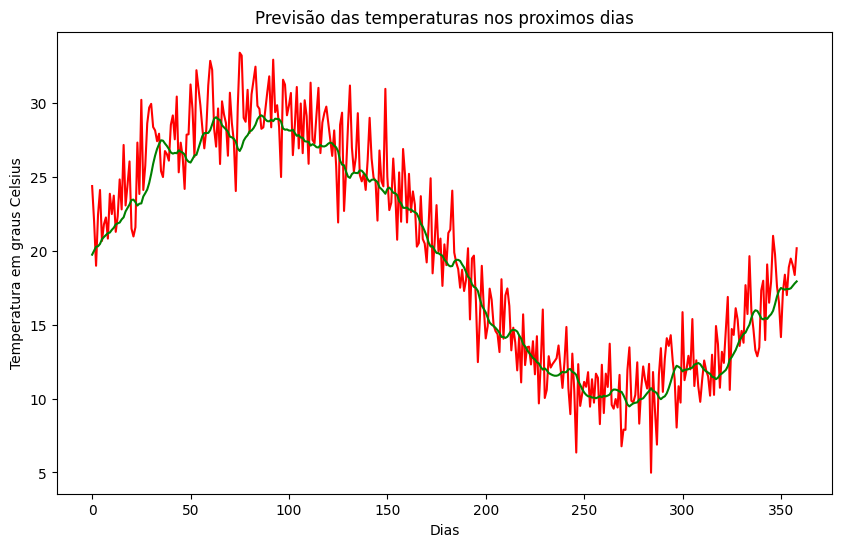

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(yteste_real, color='red', label= 'Temperatura real')
plt.plot(previsao, color='green', label = 'Previsão do modelo')
plt.title('Previsão das temperaturas nos proximos dias')
plt.xlabel('Dias')
plt.ylabel('Temperatura em graus Celsius')
plt.show()

# Salvando o modelo par uso futuro

In [13]:
modelo.save('modelo_de_previsao_temperatura.h5')